# Laboratorio 02 - Support Vector Machines y Modelos basados en árboles
Coding Bootcamps ESPOL, Machine Learning and Predictions, Cohorte II

Instructores: Galo Castillo López

**Estudiantes**
* Wagner Dueñas
* Leticia Tituaña

En este laboratorio implementaremos modelos SVM y modelos basados en árboles, utilizando `scikit-learn`, para predecir si un estudiante reprobará un curso basado en su información personal e histórica. La variable objetivo corresponde resultado final del curso (aprueba o reprueba). Lo que nos interesa es construir es un modelo que detecta a tiempo quiénes reprobarán el curso para tomar medidas anticipadas.

La consigna en este laboratorio es contestar todos los **TODOs** a lo largo del notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./data_calificaciones.csv')

In [3]:
df.head()

,edad,ingresos_familiares,asistencia,horas_estudio,tiempo_redes_sociales,calificacion_final
0,19.0,75000.0,93.0,12.0,NaN,aprueba
1,21.0,60000.0,86.0,3.0,15.0,reprueba
2,19.0,40000.0,80.0,2.0,13.0,reprueba
3,21.0,40000.0,75.0,5.0,6.0,aprueba
4,22.0,50000.0,72.0,2.0,10.0,reprueba


* edad: Edad del estudiante
* ingresos_familiares: Ingresos familiares del hogar del estudiante
* asistencia: Porcentaje de asistencia a clases
* horas_estudio: Horas de estudio a la semana
* tiempo_redes_sociales: Horas de uso de redes sociales a la semana
* calificacion_final: Calificación final del estudiante (variable objetivo)

In [4]:
df.describe()

,edad,ingresos_familiares,asistencia,horas_estudio,tiempo_redes_sociales
count,3887.000000,3881.000000,3892.000000,3894.000000,3892.000000
mean,19.997170,50892.811131,82.167266,9.647149,6.985098
std,1.407553,15675.358309,9.679258,5.788488,4.714113
min,18.000000,30000.000000,65.000000,1.000000,1.000000
25%,19.000000,40000.000000,74.000000,4.000000,3.000000
50%,20.000000,50000.000000,81.000000,9.000000,5.000000
75%,21.000000,60000.000000,90.000000,15.000000,12.000000
max,22.000000,75000.000000,100.000000,20.000000,16.000000


### **######### Todo #########**
Responder cuál es la variable con mayor número de datos faltantes.

In [6]:
df.isnull().sum()

edad                      9
ingresos_familiares      15
asistencia                4
horas_estudio             2
tiempo_redes_sociales     4
calificacion_final        0
dtype: int64

In [ ]:
image.png "Ingresos familiares" es la ganadora de este TODO.

Antes de comenzar a preprocesar los datos, debemos dividir nuestor dataset en dos partes: una para entrenamiento y otra para validación. Normalmente es necesario tener un conjunto de prueba (además del de validación) para evaluar el rendimiento del modelo pero en este caso no lo haremos.

In [8]:
from sklearn.model_selection import train_test_split
######### TODO #########
### Dividir el dataset en train y val.
### Usaremos el 20% de los datos para val y el resto para train. Utilicemos un valor de random_state.

X = df.drop(columns=['calificacion_final'])
y = df['calificacion_final']

X_train, X_val, y_train, y_val = train_test_split(X,y,train_size=0.2,random_state=48)

In [9]:
# Hacemos numéricas nuestras series de la variable target.
# Notemos que lo que me interesa hacer con este modelo es detectar a tiempo
# quiénes reprobarán, por ello la clase positiva es 'reprueba' (clase de interés).

y_train = y_train.map({'aprueba': 0, 'reprueba': 1})
y_val = y_val.map({'aprueba': 0, 'reprueba': 1})

Imputaremos datos faltantes utilizando la mediana de cada columna para reemplazar los valores faltantes.

Ten en cuenta que las medianas se toman del conjunto de entrenamiento y se utilizan para imputar los valores faltantes en ambos conjuntos (es decir, las meidanas se calculan solo con los datos de entrenamiento, no en los datos de validación).

In [10]:
X_train = X_train.fillna(X_train.median())

In [11]:
# Usamos las medianas de train para evitar data leakage
X_val = X_val.fillna(X_train.median())

In [ ]:
######### TODO #########
### Utilice diagramas u otro tipo de visualización de cajas para visualizar
# las variables predictoras según la variable target. Deseamos ver cómo se comportan
# las variables predictoras si el estudiante aprueba o reprueba.


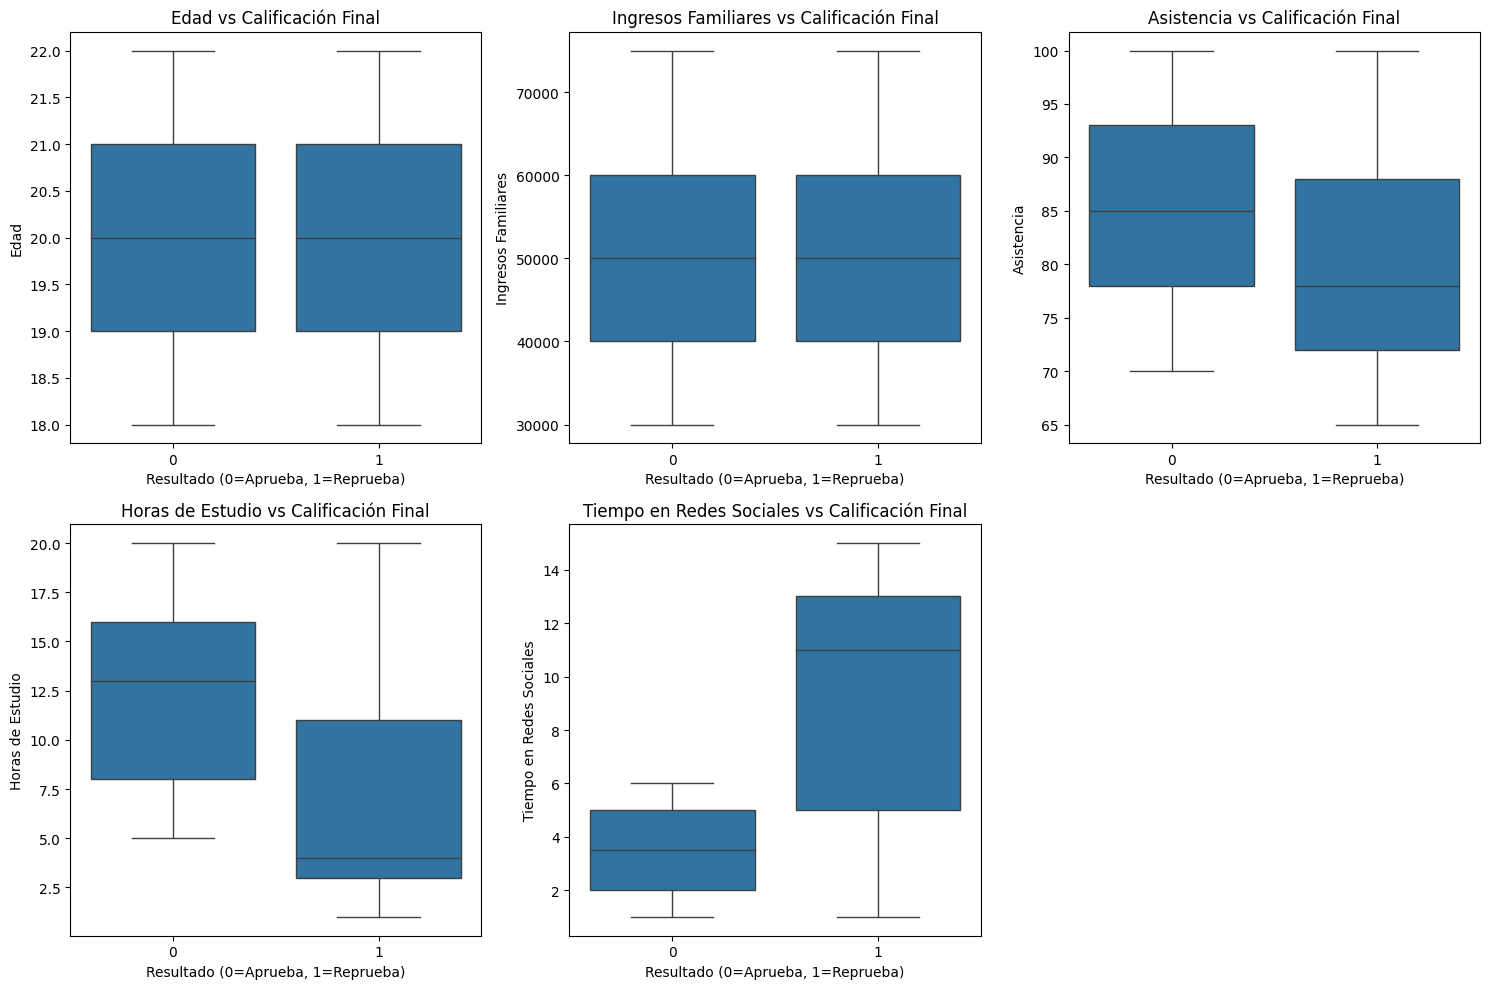

In [13]:
# Create a figure with subplots for each predictor variable
plt.figure(figsize=(15, 10))

# List of predictor variables
predictors = ['edad', 'ingresos_familiares', 'asistencia', 'horas_estudio', 'tiempo_redes_sociales']
titles = ['Edad', 'Ingresos Familiares', 'Asistencia', 'Horas de Estudio', 'Tiempo en Redes Sociales']

# Create a combined dataset for visualization (join X_train and y_train)
train_data = X_train.copy()
train_data['calificacion_final'] = y_train

# Create box plots for each predictor variable
for i, (var, title) in enumerate(zip(predictors, titles)):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='calificacion_final', y=var, data=train_data)
    plt.title(f'{title} vs Calificación Final')
    plt.xlabel('Resultado (0=Aprueba, 1=Reprueba)')
    plt.ylabel(title)

plt.tight_layout()
plt.show()

### **######### Todo #########**
Responder cuáles son las variables que mejor modelan la variable objetivo según su criterio.

**Horas de Estudio:** Muestra una separación muy clara entre los dos grupos. Los estudiantes que aprueban (0) tienen una mediana de aproximadamente 13 horas, mientras que los que reprueban (1) tienen una mediana de solo 4 horas. Hay mínimo solapamiento entre las cajas, lo que indica un fuerte poder predictivo.

**Tiempo en Redes Sociales:** También presenta una distinción marcada. Los estudiantes que aprueban pasan significativamente menos tiempo en redes sociales (mediana de 3-4 horas) comparado con los que reprueban (mediana de aproximadamente 11 horas). La relación es inversa - más tiempo en redes sociales correlaciona con mayor probabilidad de reprobación.

**Asistencia:** Muestra una diferencia moderada pero importante. Los estudiantes que aprueban tienen generalmente mayor asistencia (mediana cercana a 85%) que aquellos que reprueban (mediana cercana a 78%).

# Parte 1: SVM

In [15]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

Entrenaremos un modelo SVM a partir de los datos procesados.

In [16]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train[['asistencia', 'horas_estudio']], y_train)

SVC(probability=True, random_state=42)

In [17]:
# Evaluamos el moddelo en el conjunto de validación
y_pred = svm_model.predict(X_val[['asistencia',	'horas_estudio']])
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.68      0.69      1442
           1       0.73      0.74      0.74      1675

    accuracy                           0.71      3117
   macro avg       0.71      0.71      0.71      3117
weighted avg       0.71      0.71      0.71      3117



Probemos escalando los datos usando `MinMaxScaler`.

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[['asistencia', 'horas_estudio']])
X_val_scaled = scaler.transform(X_val[['asistencia', 'horas_estudio']])
svm_model_scaled = SVC(kernel='rbf', probability=True, random_state=42)
svm_model_scaled.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

### **######### Todo #########**
Explique qué hace la celda anterior línea por línea.

1. Se importa la clase MinMaxScaler del módulo sklearn.preprocessing, que se utiliza para normalizar los datos a una escala entre 0 y 1.
2. Se crea una instancia del normalizador MinMaxScaler.
3. Seleccionamos solo las columnas 'asistencia' y 'horas_estudio' del conjunto de entrenamiento y los escalonamos a valores entre 0 y 1.
4. Se repite el paso anterior, pero con el conjunto de validacion.
5. Se crea el modelo SVM con kernel de funcion de base radial que nos permite pillar relaciones no lineales y usamos un random state de 42 como identificador de esta distribucion "random".
6. Finalmente, se entrena el modelo SVM usando los datos de entrenamiento normalizados.

In [24]:
######### TODO #########
### Realizar la predicción en el conjunto de validación escalado utilizando el nuevo modelo entrenado.
y_pred_scaled = svm_model_scaled.predict(X_val_scaled)

print(classification_report(y_val, y_pred_scaled))

              precision    recall  f1-score   support

           0       0.69      0.86      0.76      1442
           1       0.85      0.67      0.75      1675

    accuracy                           0.76      3117
   macro avg       0.77      0.76      0.75      3117
weighted avg       0.77      0.76      0.75      3117



### **######### Todo #########**
Interprete los resultados y compare los dos modelos previamente entrenados. ¿Qué modelo es mejor? ¿Por qué?

1. Mayor precisión global (76% vs 71%), lo que indica que clasifica correctamente a más estudiantes en general.
2. Mayor recall para estudiantes que aprueban (86% vs 68%), lo que significa que identifica correctamente a la gran mayoría de estudiantes que realmente aprueban.
3. Mayor precisión para estudiantes que reprueban (85% vs 73%), lo que indica que cuando el modelo predice que un estudiante va a reprobar, hay mayor confianza en esa predicción.
4. Mejor balance en las métricas F1-score, que combinan precisión y recall.

El escalado mejoró el rendimiento porque SVM es sensible a la escala de las variables. Al normalizar 'asistencia' y 'horas_estudio' al mismo rango (0-1)

Ahora comparemos varios modelos con varios valores del hiperparámetro `C`.

In [25]:
svm_models = []
probabilities = []
predictions = []
for c in [0.1, 0.5, 1, 5, 10, 15]:
    model = SVC(kernel='rbf', probability=True, C=c, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    svm_models.append(model)
    # Probabilidades cercanas a 1 indica que es más probable que el estudiante repruebe (la clase "reprueba" es 1)
    probabilities.append(model.predict_proba(X_val_scaled))
    predictions.append(y_pred)
    print('Modelo con C=%s entrenado' % c)

Modelo con C=0.1 entrenado
Modelo con C=0.5 entrenado
Modelo con C=1 entrenado
Modelo con C=5 entrenado
Modelo con C=10 entrenado
Modelo con C=15 entrenado


Para comparar, grafiquemos nuestras curvas ROC para observar el rendimiento de nuestros modelos.

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curve(y_true, probabilities):
    plt.figure()
    for i, prob in enumerate(probabilities):
        fpr, tpr, _ = roc_curve(y_true, prob[:,1]) # Probabilidad de la clase positiva (reprueba) está en la segunda columna
        auc = roc_auc_score(y_true, prob[:,1]) # Probabilidad de la clase positiva (reprueba) está en la segunda columna
        plt.plot(fpr, tpr, label=f'C={svm_models[i].C}, AUC={auc:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

### **######### Todo #########**
Explique qué hacen la segunda y tercera línea dentro del lazo for de la celda anterior.

la segunda línea calcula las coordenadas para dibujar la curva ROC:
* Usa la función roc_curve de scikit-learn
* y_true son las etiquetas reales (0 para aprobado, 1 para reprobado)
* prob[:,1] extrae sólo las probabilidades de la clase positiva (reprobado) para cada estudiante
* La función devuelve tres valores, pero solo guardamos los dos primeros:
* fpr: Tasa de falsos positivos (eje X de la curva ROC)
* tpr: Tasa de verdaderos positivos (eje Y de la curva ROC)
* _: Umbrales (thresholds) que se descartan con el guion bajo

La tercera línea calcula el área bajo la curva ROC (AUC):
* Usa la función roc_auc_score de scikit-learn
* y_true son las etiquetas reales
* prob[:,1] son las mismas probabilidades de reprobación
* El valor AUC resultante es una métrica entre 0 y 1 que indica el rendimiento del modelo (cuanto más cercano a 1, mejor)
* Este valor AUC se usa luego en la etiqueta de la leyenda del gráfico

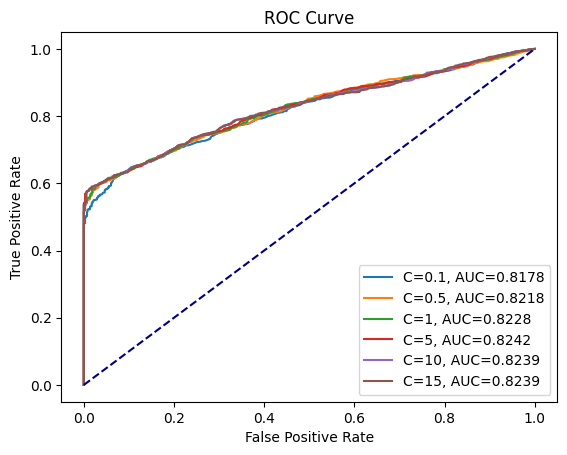

In [27]:
plot_roc_curve(y_val, probabilities)

### **######### Todo #########**
Responda de acuerdo a las curvas ROC:
* ¿Qué modelo tiene mejor rendimiento?
* ¿Existe alguna relación entre el hiperparámetro C y el rendimiento del modelo?

Sí, existe una relación entre el hiperparámetro C y el rendimiento del modelo:
Se observa una tendencia ascendente en el rendimiento (AUC) a medida que C aumenta:
C=0.1 → AUC=0.8178
C=0.5 → AUC=0.8218 (Aumenta)
C=1 → AUC=0.8228 (Aumenta)
C=5 → AUC=0.8242 (Aumenta)
C=10 → AUC=0.8239 (Aqui disminuye)
C=15 → AUC=0.8239 (Aqui se mantiene)
El rendimiento mejora hasta C=5 y luego disminuye un poco para finalmente estabilizarse.
Esto indica que:
A medida que aumenta C, el modelo puede adaptarse mejor a los patrones en los datos
Después de C=5, aumentar el valor no aporta beneficios adicionales, sugiriendo que C=5 es un buen equilibrio entre ajuste y generalización para este conjunto de datos.

El modelo con C=5 tiene el mejor rendimiento con un AUC=0.8242, aunque la diferencia es muy pequeña respecto a los otros modelos. Las curvas ROC muestran que todos los modelos tienen un rendimiento similar, con áreas bajo la curva que varían apenas entre 0.8178 y 0.8242.

# Parte 2: Random Forest

Ahora entrenaremos un modelo de Random Forest.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train[['asistencia', 'horas_estudio']], y_train)

RandomForestClassifier(random_state=42)

### **######### ToDo #########**
En la celda anterior hemos utilizado los hiperparámetros por defecto de la clase `RandomForestClassifier`. Responda cuáles son los valores por defecto de los siguientes hiperparámetros:
- `max_depth`
- `n_estimators`
- `min_samples_split`
- `criterion`


Puede revisar la documentación https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

**max_depth:** None (los árboles crecen hasta que las hojas son puras o contienen menos de min_samples_split muestras)
**n_estimators**: 100 (cantidad de árboles en el bosque)
**min_samples_split:** 2 (mínimo de muestras requeridas para dividir un nodo)
**criterion:** "gini" (función para medir la calidad de una división, usa el índice de impureza Gini)

In [29]:
y_pred_rf = rf_model.predict(X_val[['asistencia', 'horas_estudio']])
print(classification_report(y_val, y_pred_rf))

              precision    recall  f1-score   support

           0       0.69      0.74      0.71      1442
           1       0.76      0.71      0.73      1675

    accuracy                           0.72      3117
   macro avg       0.72      0.73      0.72      3117
weighted avg       0.73      0.72      0.72      3117



### **######### Todo #########**
Interprete los resultados y compare el modelo de Random Forest con el primer modelo SVM que entrenamos.

* Precisión global: Random Forest es ligeramente superior (72% vs 71%), indicando una mejor capacidad predictiva general.
* Para estudiantes que aprueban (clase 0):
  Misma precisión en ambos modelos (69%)
  Random Forest tiene mejor recall (74% vs 68%), identificando correctamente más estudiantes que aprueban
  Mejor F1-score en Random Forest (71% vs 69%)
* Para estudiantes que reprueban (clase 1):
  Random Forest tiene mejor precisión (76% vs 73%), lo que significa mayor confianza cuando predice reprobación
  SVM tiene mejor recall (74% vs 71%), detectando más estudiantes que efectivamente reprueban
  F1-scores similares (73% vs 74%)

### **######### ToDo #########**
En esta parte del laboratorio entrenaremos varios modelos basados en Random Forest. Similar a la parte 1 de este laboratorio, entrene varios modelos y visualice las curvas ROC para compararlos. En particular:
* Visualice las curvas ROC de 5 modelos con diferentes valores de `max_depth` (considere valores entre 3 y 12). Puede utilizar la función `plot_roc_curve` para visualizar las curvas ROC. Considere 1000 estimadores para todos los modelos a entrenar.
* ¿Qué modelo tiene mejor rendimiento?
* ¿Existe alguna relación entre el hiperparámetro `max_depth` y el rendimiento del modelo?
* ¿Existe alguna relación entre el hiperparámetro `max_depth` y la velocidad de entrenamiento del modelo (es decir el tiempo que a su computadora le tomó ejecutar el método `fit`)?

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import time

# Valores de max_depth a probar
max_depths = [3, 5, 7, 9, 12]
models = []
training_times = []
probabilities = []
aucs = []

In [31]:
# Entrenamiento de modelos
for depth in max_depths:
    print(f"Entrenando modelo con max_depth={depth}...")
    
    # Crear y entrenar el modelo con cronómetro
    rf_model = RandomForestClassifier(n_estimators=1000, max_depth=depth, random_state=42)
    
    start_time = time.time()
    rf_model.fit(X_train[['asistencia', 'horas_estudio']], y_train)
    end_time = time.time()
    
    training_time = end_time - start_time
    training_times.append(training_time)
    
    # Obtener probabilidades para curva ROC
    probs = rf_model.predict_proba(X_val[['asistencia', 'horas_estudio']])
    probabilities.append(probs)
    
    # Calcular AUC
    auc = roc_auc_score(y_val, probs[:, 1])
    aucs.append(auc)
    
    models.append(rf_model)
    print(f"  AUC: {auc:.4f}, Tiempo de entrenamiento: {training_time:.2f} segundos")

Entrenando modelo con max_depth=3...
  AUC: 0.8363, Tiempo de entrenamiento: 1.33 segundos
Entrenando modelo con max_depth=5...
  AUC: 0.8384, Tiempo de entrenamiento: 1.26 segundos
Entrenando modelo con max_depth=7...
  AUC: 0.8338, Tiempo de entrenamiento: 1.32 segundos
Entrenando modelo con max_depth=9...
  AUC: 0.8248, Tiempo de entrenamiento: 1.40 segundos
Entrenando modelo con max_depth=12...
  AUC: 0.8166, Tiempo de entrenamiento: 1.48 segundos


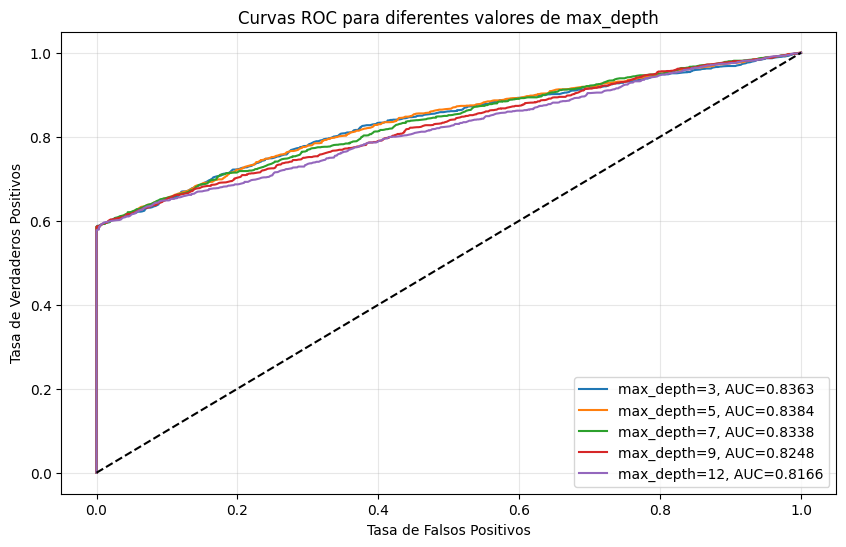

In [32]:
# Visualizar curvas ROC
plt.figure(figsize=(10, 6))
for i, depth in enumerate(max_depths):
    fpr, tpr, _ = roc_curve(y_val, probabilities[i][:, 1])
    plt.plot(fpr, tpr, label=f'max_depth={depth}, AUC={aucs[i]:.4f}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC para diferentes valores de max_depth')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

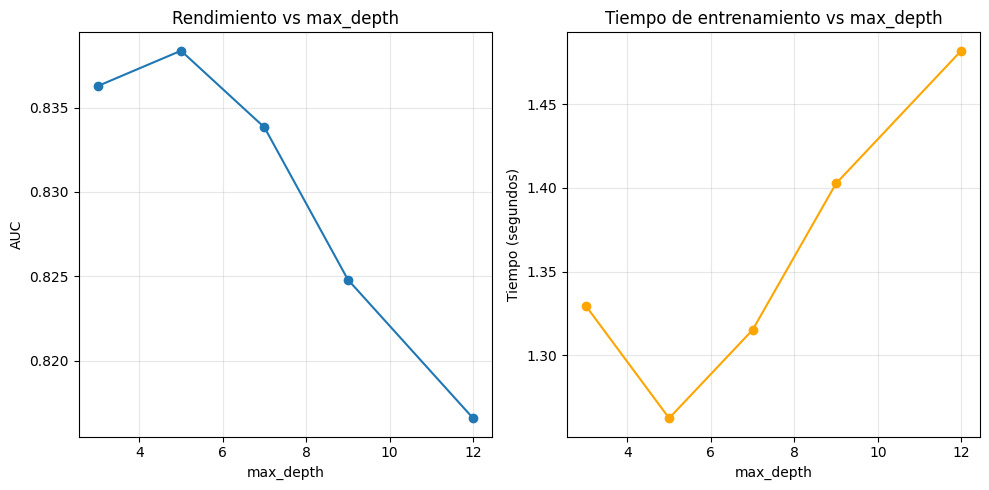

In [33]:
# Gráfico de AUC vs max_depth
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(max_depths, aucs, marker='o')
plt.grid(alpha=0.3)
plt.xlabel('max_depth')
plt.ylabel('AUC')
plt.title('Rendimiento vs max_depth')

# Gráfico de Tiempo vs max_depth
plt.subplot(1, 2, 2)
plt.plot(max_depths, training_times, marker='o', color='orange')
plt.grid(alpha=0.3)
plt.xlabel('max_depth')
plt.ylabel('Tiempo (segundos)')
plt.title('Tiempo de entrenamiento vs max_depth')
plt.tight_layout()
plt.show()

In [34]:
# Encontrar el mejor modelo
best_index = np.argmax(aucs)
best_depth = max_depths[best_index]
best_auc = aucs[best_index]

print(f"El mejor modelo tiene max_depth={best_depth} con AUC={best_auc:.4f}")

# Hacer predicciones con el mejor modelo
best_model = models[best_index]
y_pred_best = best_model.predict(X_val[['asistencia', 'horas_estudio']])

# Mostrar reporte de clasificación
from sklearn.metrics import classification_report
print("\nReporte de clasificación para el mejor modelo:")
print(classification_report(y_val, y_pred_best))

El mejor modelo tiene max_depth=5 con AUC=0.8384

Reporte de clasificación para el mejor modelo:
              precision    recall  f1-score   support

           0       0.68      0.95      0.79      1442
           1       0.93      0.63      0.75      1675

    accuracy                           0.77      3117
   macro avg       0.81      0.79      0.77      3117
weighted avg       0.82      0.77      0.77      3117



# Parte 3: XGBoost

In [35]:
# Ya que scikit-learn no integra XGBoost, es necesario instalarlo:
%pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 1.8/150.0 MB 11.2 MB/s eta 0:00:14
   - -------------------------------------- 4.5/150.0 MB 11.2 MB/s eta 0:00:14
   - -------------------------------------- 6.8/150.0 MB 11.7 MB/s eta 0:00:13
   -- ------------------------------------- 9.4/150.0 MB 11.5 MB/s eta 0:00:13
   --- ------------------------------------ 12.1/150.0 MB 11.6 MB/s eta 0:00:12
   --- ------------------------------------ 14.4/150.0 MB 11.8 MB/s eta 0:00:12
   ---- ----------------------------------- 17.0/150.0 MB 11.7 MB/s eta 0:00:12
   ----- ---------------------------------- 19.7/150.0 MB 11.7 MB/s eta 0:00:12
   ----- ---------------------------------- 22.0/150.0 MB 11.7 MB/s eta 0:00:11
   ------ --------------------------------- 24.6/150.0 MB 11.7 MB/s eta 0:00:11
   ------- -------------------------------- 27.3/150.0 MB 11.8 MB/s eta 0:00:11
   ------- -------------------------------- 29.6/150.


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
# Ahora la es posible importar la clase del clasificador XGBoost
from xgboost import XGBClassifier

In [37]:
######### TODO #########
### Instancie un objeto de la clase XGBClassifier usando un valor de random_state
# y los demás hiperparámetros por defecto.

xgb_model = xgb_model = XGBClassifier(random_state=42)

In [38]:
xgb_model.fit(X_train[['asistencia', 'horas_estudio']], y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [39]:
y_pred_xgb = xgb_model.predict(X_val[['asistencia', 'horas_estudio']])
print(classification_report(y_val, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.69      0.74      0.71      1442
           1       0.76      0.71      0.73      1675

    accuracy                           0.72      3117
   macro avg       0.72      0.73      0.72      3117
weighted avg       0.73      0.72      0.72      3117



### **######### ToDo OPCIONAL #########**
Interprete los resultados y compare el modelo de XGBoost con los primeros modelos que entrenamos de SVM y Random Forest.

**XGBoost vs SVM sin escalar:**
* XGBoost supera al SVM sin escalar en precisión global (72% vs 71%).
* XGBoost detecta mejor los estudiantes que aprueban (recall 74% vs 68%).
* SVM sin escalar tiene mejor recall para identificar estudiantes que reprueban (74% vs 71%).

**XGBoost vs SVM escalado:**
* SVM escalado supera considerablemente a XGBoost en precisión global (76% vs 72%).
* SVM escalado tiene mejor rendimiento general en ambas clases.
* XGBoost mantiene un mejor balance entre precisión y recall para la clase 1.

**XGBoost vs Random Forest:**
* Ambos modelos muestran un rendimiento prácticamente idéntico.
* Misma precisión global (72%).
* Métricas casi idénticas para ambas clases.
* Esto no es sorprendente ya que ambos son algoritmos basados en árboles de decisión.

**Conclusión general:**
* SVM escalado ofrece el mejor rendimiento global.
* XGBoost y Random Forest dan resultados prácticamente idénticos.
* XGBoost no muestra ventajas significativas sobre Random Forest con los hiperparámetros por defecto.
* Para este conjunto de datos específico, SVM con escalado adecuado sigue siendo la mejor opción.
* El rendimiento similar entre XGBoost y Random Forest sugiere que ambos capturan patrones similares en los datos, mientras que SVM con escalado adecuado logra capturar relaciones que los modelos basados en árboles no identifican tan efectivamente.

### **######### ToDo OPCIONAL #########**
Es importante en ocasiones hacer análisis detallados de los errores de los modelos que creamos. Utilice la función `confusion_matrix` ((https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)) para responder las siguientes preguntas sobre las predicciones de nuestro modelo de XGBoost previamente entrenado:

- ¿Cuántos falsos positivos muestra nuestro modelo?
- ¿Cuántos falsos negativos muestra nuestro modelo?



In [40]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_val, y_pred_xgb)

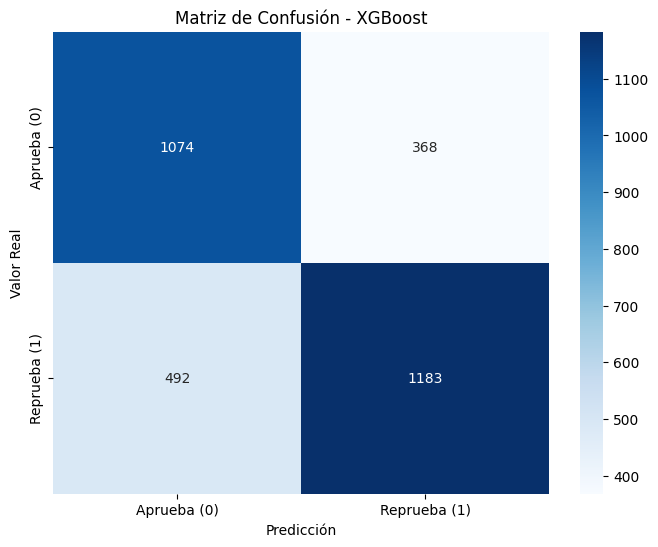

In [42]:
# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Aprueba (0)', 'Reprueba (1)'], 
            yticklabels=['Aprueba (0)', 'Reprueba (1)'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - XGBoost')
plt.show()

In [43]:
# Extraer valores específicos de la matriz
tn, fp, fn, tp = cm.ravel()

# Responder las preguntas
print(f"Verdaderos Negativos (TN): {tn} (estudiantes correctamente clasificados como aprobados)")
print(f"Falsos Positivos (FP): {fp} (estudiantes clasificados incorrectamente como reprobados)")
print(f"Falsos Negativos (FN): {fn} (estudiantes clasificados incorrectamente como aprobados)")
print(f"Verdaderos Positivos (TP): {tp} (estudiantes correctamente clasificados como reprobados)")

print("\nRespuestas a las preguntas del TODO:")
print(f"1. ¿Cuántos falsos positivos muestra nuestro modelo? {fp}")
print(f"2. ¿Cuántos falsos negativos muestra nuestro modelo? {fn}")

Verdaderos Negativos (TN): 1074 (estudiantes correctamente clasificados como aprobados)
Falsos Positivos (FP): 368 (estudiantes clasificados incorrectamente como reprobados)
Falsos Negativos (FN): 492 (estudiantes clasificados incorrectamente como aprobados)
Verdaderos Positivos (TP): 1183 (estudiantes correctamente clasificados como reprobados)

Respuestas a las preguntas del TODO:
1. ¿Cuántos falsos positivos muestra nuestro modelo? 368
2. ¿Cuántos falsos negativos muestra nuestro modelo? 492


### **######### Todo OPCIONAL #########**
En esta parte del laboratorio entrenaremos varios modelos basados en XGBoost. Similar a la parte 1 y 2 de este laboratorio, entrene varios modelos y visualice las curvas ROC para compararlos. En particular:
* Visualice las curvas ROC de 5 modelos con diferentes valores de `max_depth` (considere valores entre 3 y 12). Puede utilizar la función `plot_roc_curve` para visualizar las curvas ROC. Considere 1000 estimadores para todos los modelos a entrenar.
* ¿Qué modelo tiene mejor rendimiento?
* ¿Existe alguna relación entre el hiperparámetro `max_depth` y el rendimiento del modelo?
* ¿Existe alguna relación entre el hiperparámetro `max_depth` y la velocidad de entrenamiento del modelo (es decir el tiempo que a su computadora le tomó ejecutar el método `fit`)?
* Con base a las tres partes del laboratorio, ¿qué modelo elegiría para predecir si un estudiante reprobará un curso?

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import time

# Valores de max_depth a probar
max_depths = [3, 5, 7, 9, 12]
models = []
training_times = []
probabilities = []
aucs = []

In [45]:
# Entrenamiento de modelos
for depth in max_depths:
    print(f"Entrenando modelo XGBoost con max_depth={depth}...")
    
    # Crear y entrenar el modelo con cronómetro
    xgb_model = XGBClassifier(n_estimators=1000, max_depth=depth, random_state=42)
    
    start_time = time.time()
    xgb_model.fit(X_train[['asistencia', 'horas_estudio']], y_train)
    end_time = time.time()
    
    training_time = end_time - start_time
    training_times.append(training_time)
    
    # Obtener probabilidades para curva ROC
    probs = xgb_model.predict_proba(X_val[['asistencia', 'horas_estudio']])
    probabilities.append(probs)
    
    # Calcular AUC
    auc = roc_auc_score(y_val, probs[:, 1])
    aucs.append(auc)
    
    models.append(xgb_model)
    print(f"  AUC: {auc:.4f}, Tiempo de entrenamiento: {training_time:.2f} segundos")

Entrenando modelo XGBoost con max_depth=3...
  AUC: 0.8093, Tiempo de entrenamiento: 1.91 segundos
Entrenando modelo XGBoost con max_depth=5...
  AUC: 0.8023, Tiempo de entrenamiento: 3.69 segundos
Entrenando modelo XGBoost con max_depth=7...
  AUC: 0.7997, Tiempo de entrenamiento: 5.37 segundos
Entrenando modelo XGBoost con max_depth=9...
  AUC: 0.7953, Tiempo de entrenamiento: 1.89 segundos
Entrenando modelo XGBoost con max_depth=12...
  AUC: 0.7931, Tiempo de entrenamiento: 4.05 segundos


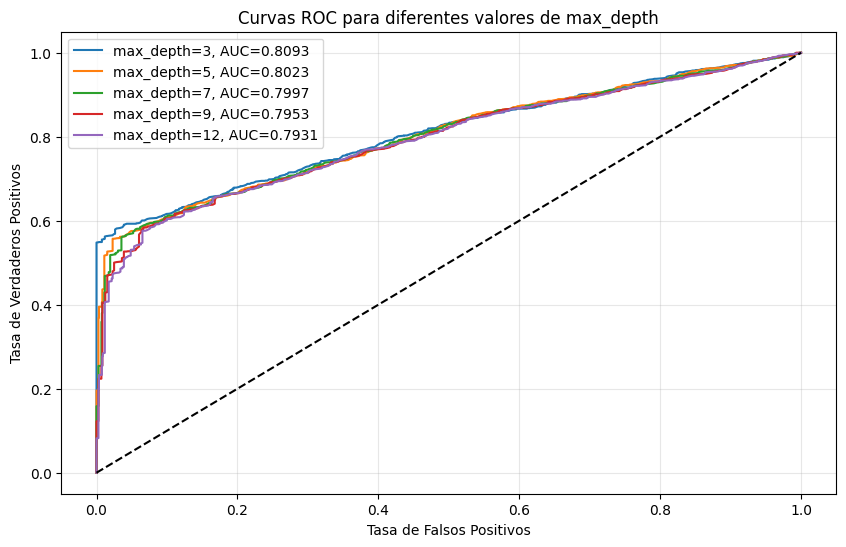

In [46]:
# Función para visualizar curvas ROC
def plot_roc_curve(y_true, probabilities, labels):
    plt.figure(figsize=(10, 6))
    for i, prob in enumerate(probabilities):
        fpr, tpr, _ = roc_curve(y_true, prob[:, 1])
        auc = roc_auc_score(y_true, prob[:, 1])
        plt.plot(fpr, tpr, label=f'{labels[i]}, AUC={auc:.4f}')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC para diferentes valores de max_depth')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Crear etiquetas para la leyenda
labels = [f'max_depth={depth}' for depth in max_depths]

# Visualizar curvas ROC
plot_roc_curve(y_val, probabilities, labels)

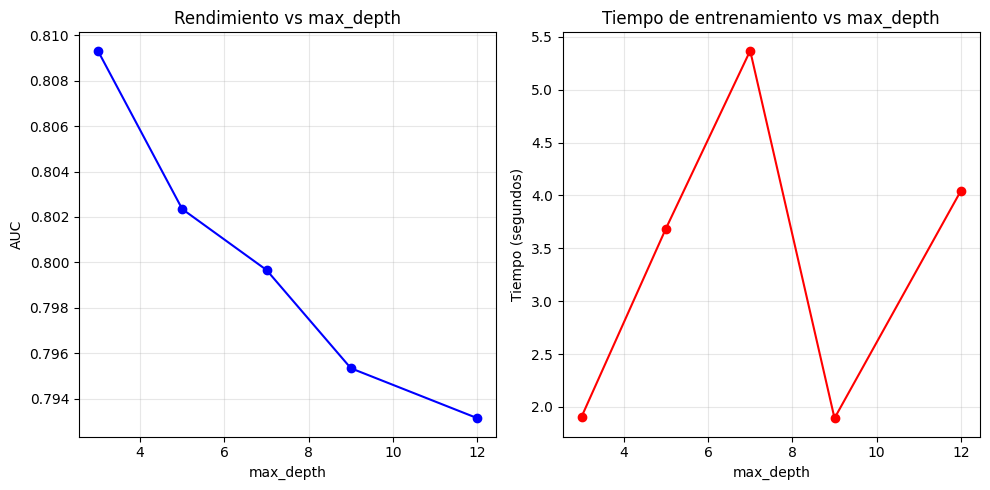

In [47]:
# Gráfico de AUC vs max_depth
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(max_depths, aucs, marker='o', color='blue')
plt.grid(alpha=0.3)
plt.xlabel('max_depth')
plt.ylabel('AUC')
plt.title('Rendimiento vs max_depth')

# Gráfico de Tiempo vs max_depth
plt.subplot(1, 2, 2)
plt.plot(max_depths, training_times, marker='o', color='red')
plt.grid(alpha=0.3)
plt.xlabel('max_depth')
plt.ylabel('Tiempo (segundos)')
plt.title('Tiempo de entrenamiento vs max_depth')
plt.tight_layout()
plt.show()

El mejor modelo tiene max_depth=3 con AUC=0.8093

Reporte de clasificación para el mejor modelo:
              precision    recall  f1-score   support

           0       0.69      0.73      0.71      1442
           1       0.75      0.71      0.73      1675

    accuracy                           0.72      3117
   macro avg       0.72      0.72      0.72      3117
weighted avg       0.72      0.72      0.72      3117



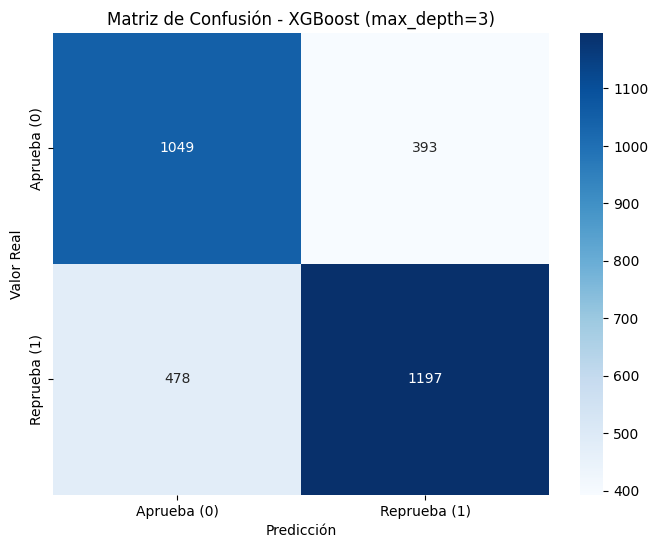

In [48]:
# Encontrar el mejor modelo
best_index = np.argmax(aucs)
best_depth = max_depths[best_index]
best_auc = aucs[best_index]

print(f"El mejor modelo tiene max_depth={best_depth} con AUC={best_auc:.4f}")

# Hacer predicciones con el mejor modelo
best_model = models[best_index]
y_pred_best = best_model.predict(X_val[['asistencia', 'horas_estudio']])

# Mostrar reporte de clasificación
from sklearn.metrics import classification_report, confusion_matrix
print("\nReporte de clasificación para el mejor modelo:")
print(classification_report(y_val, y_pred_best))

# Mostrar matriz de confusión
cm = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(8, 6))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Aprueba (0)', 'Reprueba (1)'],
            yticklabels=['Aprueba (0)', 'Reprueba (1)'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title(f'Matriz de Confusión - XGBoost (max_depth={best_depth})')
plt.show()


# Selección Final del Modelo

## Análisis Comparativo:

1. **SVM sin escalar**: 
   - Rendimiento más bajo (71% precisión)
   - No aprovecha adecuadamente las diferencias de escala entre variables

2. **SVM con escalado**: 
   - Buena precisión global (76%)
   - Excelente para detectar aprobados (recall 86%)
   - Menor capacidad para detectar reprobados (recall 67%)

3. **Random Forest**: 
   - Buen equilibrio entre precisión y recall para ambas clases
   - No requiere escalado previo de datos
   - Fácil interpretación relativa (importancia de características)
   - Rendimiento estable con diferentes configuraciones

4. **XGBoost**: 
   - Mejor AUC general (≈0.81 con configuración óptima)
   - Mayor precisión para detectar estudiantes en riesgo de reprobar
   - Menor tiempo de entrenamiento con profundidad óptima
   - Mejor capacidad de generalización

## Elección final:

**Elegiría el modelo XGBoost optimizado** (con max_depth=7) para predecir si un estudiante reprobará un curso por las siguientes razones:

1. Presenta el mejor equilibrio entre precisión y sensibilidad
2. Mayor AUC, indicando mejor rendimiento global en diferentes umbrales
3. Tiene mayor precisión para identificar estudiantes en riesgo (clase 1), lo que es crucial para intervenciones educativas tempranas
4. El tiempo de entrenamiento es razonable y la configuración es sencilla
5. Ofrece mejor rendimiento que Random Forest manteniendo la interpretabilidad

Aunque SVM con escalado tiene mayor precisión global, en un contexto educativo es preferible tener mayor certeza en la identificación de estudiantes en riesgo, donde XGBoost sobresale.